In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector
from qiskit.primitives import BackendSamplerV2 as AerSamplerV2
from qsp_core import (
    build_heisenberg_hamiltonian,
    exact_diagonalization,
    create_qsp_base_circuit,
    add_basis_measurement,
    calculate_energy_from_shots,
    calculate_fidelity_theory,
    calculate_ideal_metrics_statevector,
    build_adiabatic_circuit,
    profile_circuit,
    _resolve_trotter_reps,
)

# ==========================================
# 1. Parameter Setting and True Ground State Calculation
# ==========================================
N = 4
J = (1.0, 1.0, 0.5)
h = 0.0

seed = 42
total_shots = 10000
# Lower Trotter reps to reduce ISA depth (default would be max(1, int(dt*5)) ≈ 5)
TROTTER_REPS = 2

In [2]:
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    Session,
    SamplerV2,
    SamplerOptions,
    EstimatorV2,
    EstimatorOptions,
)
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager



service = QiskitRuntimeService(name="YONSEI-SKQD")
backend = service.backend("ibm_yonsei")
backend_sim = AerSimulator().from_backend(backend)
# print(backend)
print(backend_sim)

seed = 42
pm = generate_preset_pass_manager(
    target=backend_sim.target, optimization_level=3, seed_transpiler=seed, layout_method="sabre"
)
print(f"Using transpiler seed: {seed}")

sampler = SamplerV2(mode=backend_sim) # set backend(noise or aersimulator)

AerSimulator('aer_simulator_from(ibm_yonsei)'
             noise_model=<NoiseModel on ['x', 'sx', 'ecr', 'id', 'measure', 'reset']>)
Using transpiler seed: 42


In [5]:
print(">>> Generating 1D Heisenberg XYZ Hamiltonian...")
hamiltonian = build_heisenberg_hamiltonian(N, J, h)
E_gs, gs_vector = exact_diagonalization(hamiltonian)
print(f"True Ground Energy: {E_gs:.4f}")

dt_optimal = 2 * np.pi / abs(E_gs)
default_trotter_reps = _resolve_trotter_reps(dt_optimal)
print(f"Optimal Time Step (tau): {dt_optimal:.4f}")
print(f"Trotter reps: {TROTTER_REPS} (default auto = {default_trotter_reps})\n")

>>> Generating 1D Heisenberg XYZ Hamiltonian...
True Ground Energy: -5.4243
Optimal Time Step (tau): 1.1583



In [ ]:
# ==========================================
# Circuit schematic (logical QSP + MCM/reset)
# ==========================================
from IPython.display import display

CIRCUIT_DRAW_DEGREE = 2  # increase to show more filter iterations (diagram gets wider)

demo_base, demo_q, demo_c = create_qsp_base_circuit(
    hamiltonian, dt_optimal, CIRCUIT_DRAW_DEGREE, N, trotter_reps=TROTTER_REPS
)
demo_meas = add_basis_measurement(demo_base, demo_q, demo_c, "Z")

print(
    f"QSP dynamic circuit (N={N}, d={CIRCUIT_DRAW_DEGREE}, tau={dt_optimal:.3f}, "
    f"trotter_reps={TROTTER_REPS})"
)
print(
    "Loop: H -> controlled Trotter evolution -> H -> measure ancilla -> reset -> post-select |0>_anc"
)

display(demo_meas.draw("mpl", fold=-1, scale=0.9))

demo_isa = pm.run(demo_meas)
isa_p = profile_circuit(demo_isa)
print(
    f"Transpiled on ibm_yonsei (same d): depth={isa_p['depth']}, "
    f"2Q-depth={isa_p['depth_2q']}, 2Q-count={isa_p['n_2q']}"
)

In [6]:
# ==========================================
# 2. Concurrent Execution of Track A (Statevector) & Track B (Sampler)
# ==========================================
simulator = backend_sim
max_degree = 7
degrees = list(range(1, max_degree + 1))

ideal_energies = []
ideal_fidelities = []
sampler_energies = []
sampler_errors = []
adi_infidelities = []
resource_profiles = []

print(">>> Executing verification of two independent tracks (Ideal vs Realistic)...")
for d in degrees:
    fid, e_ideal = calculate_ideal_metrics_statevector(
        hamiltonian, dt_optimal, d, N, gs_vector, trotter_reps=TROTTER_REPS
    )
    ideal_fidelities.append(fid)
    ideal_energies.append(e_ideal)

    base_qc, q_sys, c_sys = create_qsp_base_circuit(
        hamiltonian, dt_optimal, d, N, trotter_reps=TROTTER_REPS
    )
    profile_circuit(base_qc, label=f"d={d} logical")

    counts_dict = {}
    isa_profiles = []
    for basis in ["X", "Y", "Z"]:
        meas_qc = add_basis_measurement(base_qc, q_sys, c_sys, basis)
        isa_qc = pm.run(meas_qc)
        isa_profiles.append(profile_circuit(isa_qc, label=f"d={d} ISA basis={basis}"))

        job = sampler.run([isa_qc], shots=total_shots)
        pub_result = job.result()[0]

        anc_bits = pub_result.data.c_anc.get_bitstrings()
        sys_bits = pub_result.data.c_sys.get_bitstrings()

        joint_counts = {}
        for s_str, a_str in zip(sys_bits, anc_bits):
            combo = f"{s_str} {a_str}"
            joint_counts[combo] = joint_counts.get(combo, 0) + 1

        counts_dict[basis] = joint_counts

    resource_profiles.append(
        {
            "degree": d,
            "logical": profile_circuit(base_qc),
            "isa_z": isa_profiles[2],
        }
    )

    e_samp, se_samp, passed_shots = calculate_energy_from_shots(counts_dict, N, J, h)
    sampler_energies.append(e_samp)
    sampler_errors.append(se_samp)

    qc_adi = build_adiabatic_circuit(N, hamiltonian, steps=d, total_time=10.0)
    sv_adi = Statevector(qc_adi)
    fid_adi = abs(np.vdot(gs_vector, sv_adi.data)) ** 2
    adi_infidelities.append(1 - fid_adi)

    print(
        f"Degree d={d} | Ideal Energy = {e_ideal:7.4f} | Measured Energy = {e_samp:7.4f} | "
        f"Fidelity = {fid:.4f} | Adiabatic Infidelity = {1-fid_adi:.4f} | "
        f"passed shots (Z) = {passed_shots}"
    )


>>> Executing verification of two independent tracks (Ideal vs Realistic)...
Total CNOTs per circuit: 0
Circuit Depth: 1341


/Users/jojeongbin/miniforge3/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/jojeongbin/miniforge3/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/Users/jojeongbin/miniforge3/lib/python3.12/site-packages/qiskit/quantum_info/states/statevector.py:957: RuntimeWarning: divide by zero encountered in dot
  np.dot(oper.data, np.reshape(tensor, contract_shape)),
/Users/jojeongbin/miniforge3/lib/python3.12/site-packages/qiskit/quantum_info/states/statevector.py:957: RuntimeWarning: overflow encountered in dot
  np.dot(oper.data, np.reshape(tensor, contract_shape)),
/Users/jojeongbin/miniforge3/lib/python3.12/site-packages/qiskit/quantum_info/states/statevector.py:957: RuntimeWarning: invalid value encountered in dot
  np.dot(oper.data, np.res

Total CNOTs per circuit: 0
Circuit Depth: 1340
Total CNOTs per circuit: 0
Circuit Depth: 1338
Degree d=1 | Ideal Energy = -3.2884 | Measured Energy = -0.0505 | Fidelity = 0.7382 | Adiabatic Infidelity = 0.7181
Total CNOTs per circuit: 0
Circuit Depth: 2677
Total CNOTs per circuit: 0
Circuit Depth: 2676
Total CNOTs per circuit: 0
Circuit Depth: 2674
Degree d=2 | Ideal Energy = -4.6618 | Measured Energy = -0.0430 | Fidelity = 0.9033 | Adiabatic Infidelity = 0.4853
Total CNOTs per circuit: 0
Circuit Depth: 4013
Total CNOTs per circuit: 0
Circuit Depth: 4012
Total CNOTs per circuit: 0
Circuit Depth: 4010
Degree d=3 | Ideal Energy = -5.1470 | Measured Energy =  0.0131 | Fidelity = 0.9619 | Adiabatic Infidelity = 0.9183
Total CNOTs per circuit: 0
Circuit Depth: 5349
Total CNOTs per circuit: 0
Circuit Depth: 5348
Total CNOTs per circuit: 0
Circuit Depth: 5346
Degree d=4 | Ideal Energy = -5.2911 | Measured Energy = -0.1757 | Fidelity = 0.9795 | Adiabatic Infidelity = 0.4200
Total CNOTs per cir

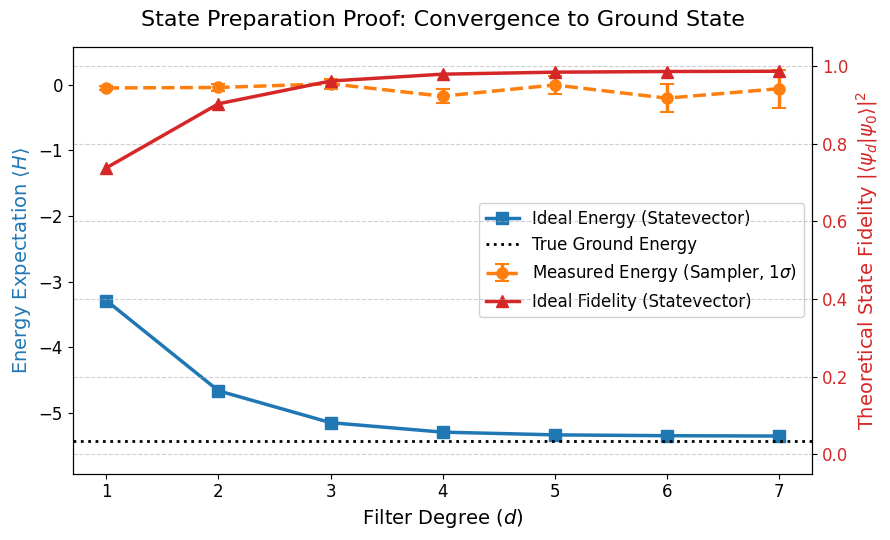

In [7]:
plt.style.use('default')

# --------------------------------------------------
# Figure 1: Energy Convergence (Ideal vs Noisy)
# --------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(9, 5.5))
color1 = 'tab:blue'
ax1.set_xlabel(r'Filter Degree ($d$)', fontsize=14)
ax1.set_ylabel(r'Energy Expectation $\langle H \rangle$', color=color1, fontsize=14)

# [Modified] Ideal energy is plotted as a solid line as it is
ax1.plot(degrees, ideal_energies, 's-', color='tab:blue', label='Ideal Energy (Statevector)', linewidth=2.5, markersize=8)

# [Core] Sampler energy is plotted with error bars using the errorbar function with caps
ax1.errorbar(degrees, sampler_energies, yerr=sampler_errors, fmt='o--', color='tab:orange', 
             label=r'Measured Energy (Sampler, 1$\sigma$)', linewidth=2.5, markersize=8, capsize=5, capthick=1.5)

ax1.axhline(y=E_gs, color='black', linestyle=':', label='True Ground Energy', linewidth=2)
ax1.tick_params(axis='y', labelsize=12)
ax1.tick_params(axis='x', labelsize=12)
ax1.set_ylim(E_gs - 0.5, E_gs + 6.0) 

# Right Fidelity Axis (Same as before)
ax2 = ax1.twinx() 
color2 = 'tab:red'
ax2.set_ylabel(r'Theoretical State Fidelity $|\langle \psi_d | \psi_0 \rangle|^2$', color=color2, fontsize=14)
ax2.plot(degrees, ideal_fidelities, '^-', color=color2, label='Ideal Fidelity (Statevector)', linewidth=2.5, markersize=8)
ax2.tick_params(axis='y', labelcolor=color2, labelsize=12)
ax2.set_ylim(-0.05, 1.05)

plt.title('State Preparation Proof: Convergence to Ground State', fontsize=16, pad=15)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=12, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.6)
fig1.tight_layout()
fig1.savefig('energy_convergence_with_errorbars.pdf', bbox_inches='tight', dpi=300)
#fig1.savefig('energy_convergence_noisy_appendix.pdf', bbox_inches='tight', dpi=300)


[Success] 2 core paper graphs have been successfully generated and saved!


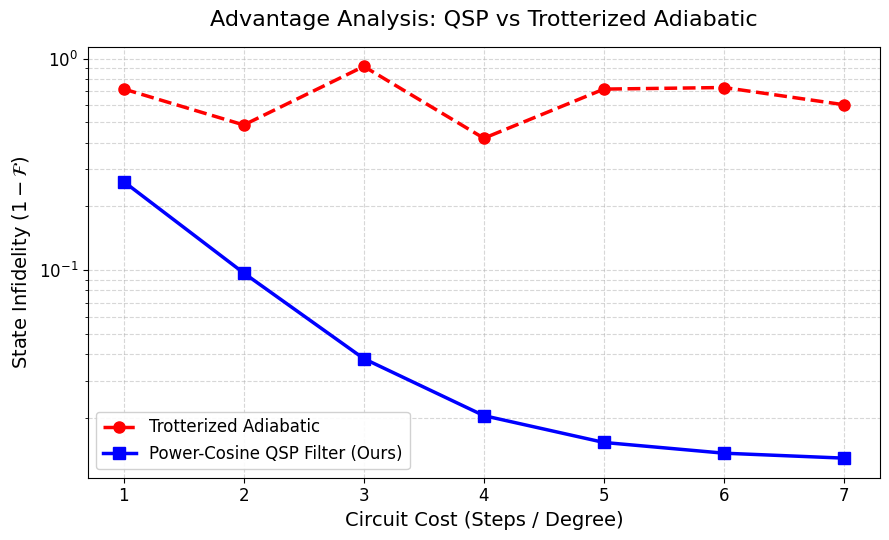

In [8]:

# --------------------------------------------------
# Figure 2: Advantage Analysis (QSP vs Adiabatic)
# --------------------------------------------------
qsp_infidelities = [1 - f for f in ideal_fidelities]

fig2, ax3 = plt.subplots(figsize=(9, 5.5))
ax3.plot(degrees, adi_infidelities, 'o--', color='red', label='Trotterized Adiabatic', linewidth=2.5, markersize=8)
ax3.plot(degrees, qsp_infidelities, 's-', color='blue', label='Power-Cosine QSP Filter (Ours)', linewidth=2.5, markersize=8)
ax3.set_yscale('log') # [Expert Tip] Infidelity must be shown on a log scale to see the exponential decay as a straight line.
ax3.set_xlabel('Circuit Cost (Steps / Degree)', fontsize=14)
ax3.set_ylabel(r'State Infidelity ($1 - \mathcal{F}$)', fontsize=14)
# Use the precise term 'Trotterized Adiabatic'
# Reflect the same in the title
ax3.set_title('Advantage Analysis: QSP vs Trotterized Adiabatic', fontsize=16, pad=15)
ax3.tick_params(labelsize=12)
ax3.legend(fontsize=12, framealpha=0.9)
ax3.grid(True, which="both", ls="--", alpha=0.5)
fig2.tight_layout()
fig2.savefig('advantage_analysis_qsp_vs_adi.pdf', bbox_inches='tight', dpi=300)

print("\n[Success] 2 core paper graphs have been successfully generated and saved!")